### Purpose
> Compute the DOS at energies around $E=0$ and see how it converges  
> Use small structure to ease computations  
> Use `nk1=250` for now, but this should be converged later

In [2]:
import numpy as np
import sisl
from tqdm.auto import tqdm
from generator import calculate_spectral_GF, systemInit, setup_ham_rse


#### Standard plotting settings

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from pathlib  import Path
import matplotlib.cm as cm
import matplotlib.colors as colors
sns.set_theme(style="white", context="notebook")

plt.rcParams.update({
    "font.family": "serif",        # Use serif for a formal/academic look
    "font.size": 9,               # Base font size
    "axes.titlesize": 18,          # Subplot titles (your .set(title=...) calls)
    "axes.labelsize": 14,          # X and Y axis labels
    "xtick.labelsize": 10,         # Size of numbers on X-axis
    "ytick.labelsize": 10,         # Size of numbers on Y-axis
    "legend.fontsize": 14,         # Legend text
    "figure.titlesize": 20,        # Overall figure title
    "axes.labelpad": 10,           # Distance between label and axis
    "mathtext.fontset": "cm",      # Computer Modern (LaTeX look for math)
    "savefig.dpi": 300             # High-res exports
})

REAL_PART_CMP = sns.color_palette("vlag", as_cmap=True)

In [ ]:
ETAS = np.array([1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
DELTA_E = 0.1
EMAX = 0.5
EMIN = -EMAX
ENERGIES = np.arange(EMIN, EMAX+DELTA_E/2, DELTA_E)
# ENERGIES = np.array([0])
N0 = N1 = 8
NK1 = 500

In [83]:
OUTPUTS = {}
for i, val_eta in enumerate(tqdm(ETAS, desc="Looping etas")):
    val_eta = val_eta*1j
    Ham0 = systemInit(bond=1.43, t=-2.7)
    H_final, rse, alist, elist = setup_ham_rse(Ham0, N0, NK1, val_eta)
    OUTPUTS[f"{np.abs(val_eta)}"] = calculate_spectral_GF(ENERGIES, val_eta, H_final, rse, alist, elist)
print(OUTPUTS.keys())
print(OUTPUTS[list(OUTPUTS.keys())[0]].keys())

Looping etas:   0%|          | 0/7 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/11 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/11 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/11 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/11 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/11 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/11 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/11 [00:00<?, ?it/s]

dict_keys(['0.1', '0.05', '0.01', '0.005', '0.001', '0.0005', '0.0001'])
dict_keys(['E', 'eta', 'H_re', 'electrode_idx', 'atoms_idx', 'GF', 'RSE_re'])


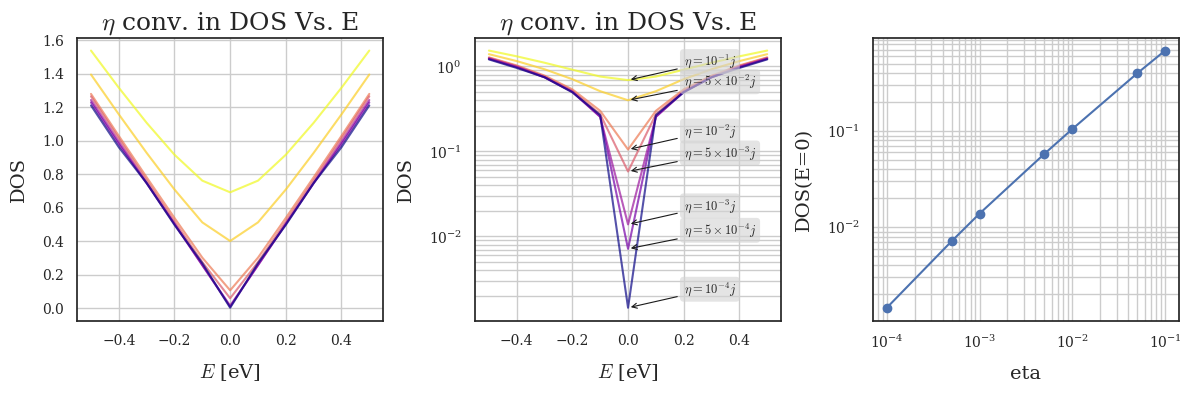

In [108]:
def _get_dos(current):
    E = current["E"]
    alist = current["atoms_idx"]
    elist = current["electrode_idx"]
    nelec = len(elist)
    GF = current["GF"]
    diag = np.diagonal(GF, axis1=1, axis2=2)
    
    ldos = -(1.0/np.pi)*np.imag(diag)
    ldos_dev = ldos[:, nelec:]

    dos_dev = np.sum(ldos_dev, axis=1)
    return E, ldos_dev, dos_dev

def format_label(value):
    exponent = int(np.floor(np.log10(value)))
    mantissa = value / (10**exponent)
    if mantissa == 1:
        return rf"$10^{{{exponent}}}$"
    return rf"${mantissa:.0f} \times 10^{{{exponent}}}$"

def plot_dos(d, eta_input):
    etas = np.array(list(map(float, d.keys())))
    Neta = len(etas)
    norm = colors.LogNorm(vmin=np.min(etas), vmax=np.max(etas))
    colormap = cm.plasma
    
    fig, ax = plt.subplots(1, 3, figsize=(12,4))
    list_of_DOSE0 = []
    for val_eta in etas:
        current = d[str(val_eta)]
        energies, ldos_dev, dos_dev = _get_dos(current)
        E0idx = np.searchsorted(energies.round(8), 0)
        line_color = colormap(norm(val_eta))
        list_of_DOSE0.append(dos_dev[E0idx])
        
        ax[0].plot(energies, dos_dev, label=f"{format_label(val_eta)}", alpha=0.7, color=line_color)
        ax[1].semilogy(energies, dos_dev, label=f"{format_label(val_eta)}", alpha=0.7, color=line_color)
        ax[1].annotate(xy=(energies[E0idx], dos_dev[E0idx]), xytext=(energies[E0idx]+0.2, dos_dev[E0idx]*1.5), text=fr"$\eta=${format_label(val_eta)}$j$", 
                    arrowprops=dict(arrowstyle="->", color="k", lw=0.8),
                    bbox=dict(boxstyle="round,pad=0.3", fc="lightgrey", ec="none", alpha=0.6))
        # ax[0].annotate(xy=(energies[E0idx], dos_dev[E0idx]), xytext=(-(energies[E0idx]+0.2), dos_dev[E0idx]*1.5), text=f"{format_label(dos_dev[E0idx])}", 
        #             arrowprops=dict(arrowstyle="->", color="k", lw=0.8),
        #             bbox=dict(boxstyle="round,pad=0.3", fc="lightgrey", ec="none", alpha=0.6))   
        
    for i in [0,1]:
        ax[i].set(xlabel=r"$E$ [eV]",
           ylabel=r"DOS",
           title="$\\eta$ conv. in DOS Vs. E")
        ax[i].grid(True, which="both", ls="-", alpha=1)
    

    
    
    ax[2].loglog(etas, list_of_DOSE0, '-o')
    ax[2].grid(True, which="both")
    ax[2].set(xlabel="eta", ylabel="DOS(E=0)")
    
    fig.tight_layout()
    

plot_dos(OUTPUTS, 1e-3)
    
    